In [1]:
import pandas as pd
import numpy as np

In [4]:
# Load avocado dataset
df_avocado = pd.read_csv("/Users/melaniehuang/Desktop/Machine Learning/Labs/Lab2/avocado-updated-2020.csv")
df_avocado

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,geography
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.00,conventional,2015,Albany
1,2015-01-04,1.79,1373.95,57.42,153.88,0.00,1162.65,1162.65,0.00,0.00,organic,2015,Albany
2,2015-01-04,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.00,conventional,2015,Atlanta
3,2015-01-04,1.76,3846.69,1500.15,938.35,0.00,1408.19,1071.35,336.84,0.00,organic,2015,Atlanta
4,2015-01-04,1.08,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.00,conventional,2015,Baltimore/Washington
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33040,2020-11-29,1.47,1583056.27,67544.48,97996.46,2617.17,1414878.10,906711.52,480191.83,27974.75,organic,2020,Total U.S.
33041,2020-11-29,0.91,5811114.22,1352877.53,589061.83,19741.90,3790665.29,2197611.02,1531530.14,61524.13,conventional,2020,West
33042,2020-11-29,1.48,289961.27,13273.75,19341.09,636.51,256709.92,122606.21,134103.71,0.00,organic,2020,West
33043,2020-11-29,0.67,822818.75,234688.01,80205.15,10543.63,497381.96,285764.11,210808.02,809.83,conventional,2020,West Tex/New Mexico


**1. Briefly describe the data set. What information does it contain?**

**The dataset has dates, the average price, total volume, total bags, and the num of bags for each type of bag (small, large, xlarge), avocado type, year, and area that it is from(geography). I am unsure of what the 4046, 4225, and 4770 columns represent.**

**2. Clean the data in any way you see fit.**

In [5]:
# rename the PLU
df_avocado = df_avocado.rename(columns = {
    "4046": "small volume",
    "4225": "large volume",
    "4770": "xlarge volume"
})

# section off the geography column to diff areas (national, major region, metro region)
national = {"Total U.S."}
 
major_region = {
    "Midsouth", "Northeast", "Southeast", "West",
}
 
# take the other ones not in national and major and put it into metro
df_avocado["geography_type"] = np.select(
    condlist=[df_avocado["geography"].isin(national), df_avocado["geography"].isin(major_region)],
    choicelist=["national", "major region"],
    default="metro region",
)
  
avocado_metro = df_avocado[df_avocado["geography_type"] == "metro region"].copy()
avocado_region = df_avocado[df_avocado["geography_type"] == "major region"].copy()
avocado_national = df_avocado[df_avocado["geography_type"] == "national"].copy()
 

**3. Which major geographical region sold the most total organic, small Hass avocados in 2017?**

In [6]:
major_organic_small_2017 = (df_avocado[(df_avocado["type"]=="organic") & (df_avocado["year"]==2017) & (df_avocado["geography_type"]=="major region")]).groupby("geography")["small volume"]
major_organic_small_2017.sum().sort_values(ascending=False)

geography
West         1870206.29
Northeast     925832.36
Southeast     285124.34
Midsouth      186395.50
Name: small volume, dtype: float64

**The west sold the most total organic, small Hass avocados in 2017.**

**4. Split the date variable into month, day, and year variables. In which month is the highest average volume of avocado sales?**

In [10]:
df_avocado["date"] = pd.to_datetime(df_avocado["date"])

df_avocado["month"] = df_avocado["date"].dt.month
df_avocado["day"] = df_avocado["date"].dt.day

In [12]:
high_avg_month = df_avocado.groupby("month")["total_volume"]
high_avg_month.mean().sort_values(ascending=False)

month
5     1.123632e+06
2     1.095374e+06
6     1.051247e+06
4     1.016582e+06
3     9.957150e+05
1     9.853122e+05
7     9.832681e+05
8     9.499249e+05
9     9.064773e+05
10    8.446863e+05
11    8.223470e+05
12    8.076695e+05
Name: total_volume, dtype: float64

**Month 5 (May) had the highest average total volume of avocado sales.**

**5. Which metro area geographical regions sold the most total avocados? Plot side-by-side box-plots of the total volume for only the five metro geographical regions with the highest averages for the total_volume variable.**

In [27]:
total_metro = df_avocado[df_avocado["geography_type"] == "metro region"].groupby("geography")["total_volume"]
total_metro = total_metro.mean().sort_values(ascending=False).head().index.tolist()
total_metro

top_five = df_avocado[df_avocado["geography"].isin(total_metro)]
top_five

,date,average_price,total_volume,small volume,large volume,xlarge volume,total_bags,small_bags,large_bags,xlarge_bags,type,year,geography,geography_type,month,day
12,2015-01-04,0.93,5777334.90,2843648.26,2267755.26,137479.64,528451.74,477193.38,47882.56,3375.80,conventional,2015,California,metro region,1,4
13,2015-01-04,1.24,142349.77,107490.73,25711.96,2.93,9144.15,9144.15,0.00,0.00,organic,2015,California,metro region,1,4
30,2015-01-04,1.02,3382800.12,467259.47,2059657.71,318102.38,537780.56,412779.64,111072.91,13928.01,conventional,2015,Great Lakes,metro region,1,4
31,2015-01-04,1.54,61615.10,3633.93,42963.06,0.00,15018.11,9763.55,5254.56,0.00,organic,2015,Great Lakes,metro region,1,4
44,2015-01-04,0.85,2682159.95,1837999.65,524430.47,64225.78,255504.05,215571.80,36981.72,2950.53,conventional,2015,Los Angeles,metro region,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32982,2020-11-29,1.74,135939.83,6283.66,1658.88,4.65,127992.64,63390.70,64601.94,0.00,organic,2020,Los Angeles,metro region,11,29
33007,2020-11-29,0.87,1886410.30,704666.67,349440.89,804.26,831498.48,653103.29,176277.54,2117.65,conventional,2020,Plains,metro region,11,29
33008,2020-11-29,1.19,55562.93,4307.70,1777.03,24.61,49453.59,45859.97,3593.62,0.00,organic,2020,Plains,metro region,11,29
33027,2020-11-29,0.64,6504704.07,2341008.09,655814.05,168632.40,3339249.53,1904298.25,1399535.07,35416.21,conventional,2020,South Central,metro region,11,29


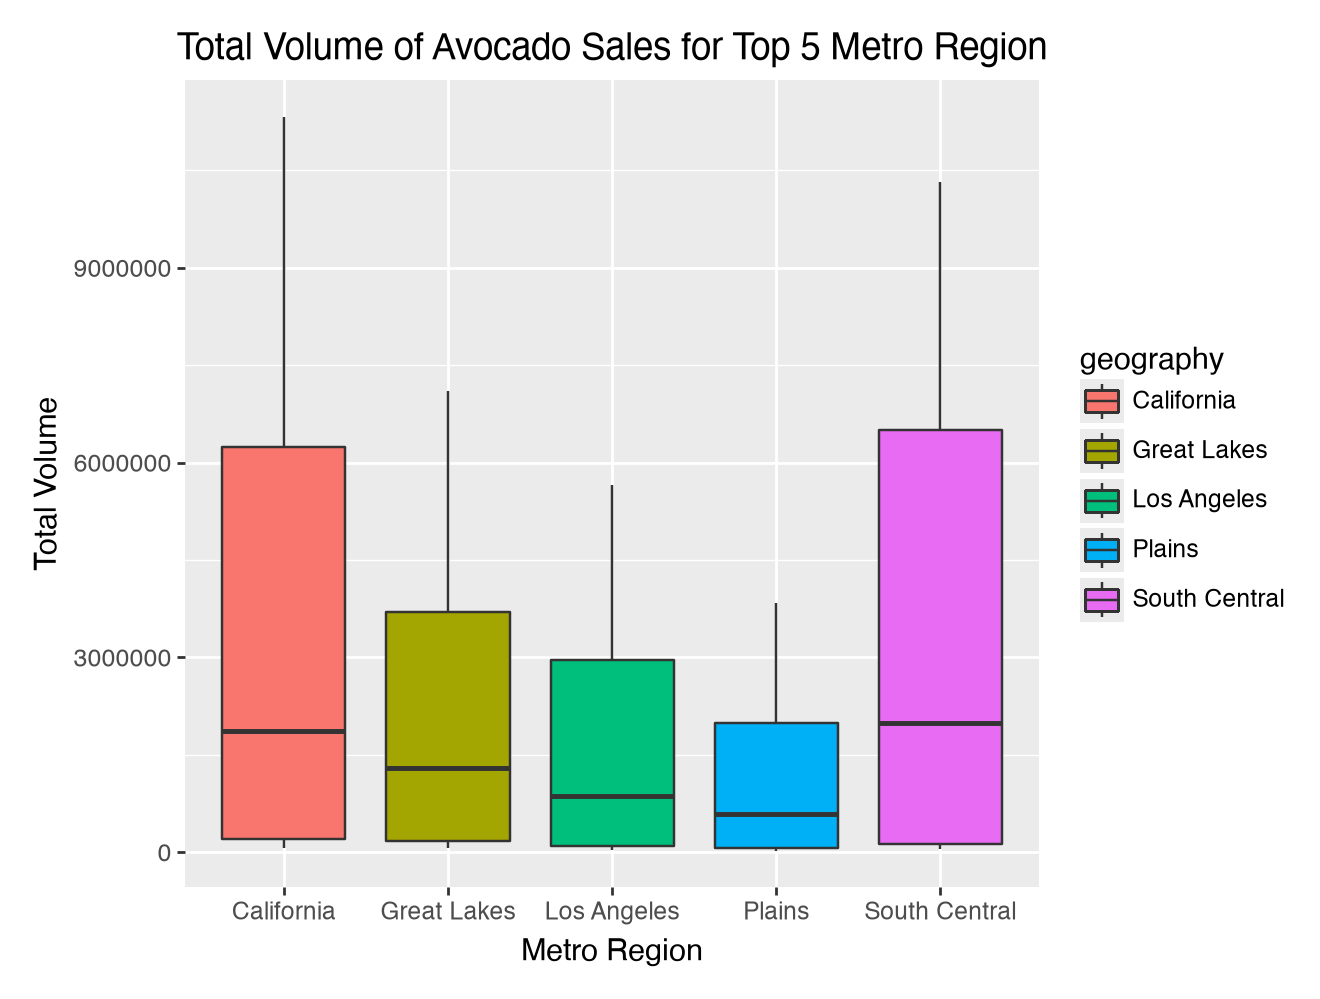

In [28]:
from plotnine import *

(ggplot(top_five, aes(x = "geography", y = "total_volume"))
 + geom_boxplot(aes(fill = "geography"))
 + labs(
    title = 'Total Volume of Avocado Sales for Top 5 Metro Region',
    x = 'Metro Region',
    y = 'Total Volume'
 )
)

In [29]:
total_metro

['South Central', 'California', 'Great Lakes', 'Los Angeles', 'Plains']

**South Central, California, Great Lakes, Los Angeles, Plains have the top 5 largest amount of total volume.**

**The following four California geographical regions are in this data set: "Los Angeles", "San Diego", "Sacramento", and "San Francisco".**

**6. From your cleaned data set, create a data set with only these California regions and answer the following questions about these California regions only.**

In [32]:
California_regions = ["Los Angeles", "San Diego", "Sacramento", "San Francisco"]

df_california_avocado = df_avocado[df_avocado["geography"].isin(California_regions)]
df_california_avocado

,date,average_price,total_volume,small volume,large volume,xlarge volume,total_bags,small_bags,large_bags,xlarge_bags,type,year,geography,geography_type,month,day
44,2015-01-04,0.85,2682159.95,1837999.65,524430.47,64225.78,255504.05,215571.80,36981.72,2950.53,conventional,2015,Los Angeles,metro region,1,4
45,2015-01-04,1.25,54495.54,47721.51,1723.40,0.00,5050.63,5050.63,0.00,0.00,organic,2015,Los Angeles,metro region,1,4
80,2015-01-04,1.05,430138.88,110693.69,270107.61,9737.50,39600.08,39600.08,0.00,0.00,conventional,2015,Sacramento,metro region,1,4
81,2015-01-04,1.33,9213.49,3727.52,4327.52,0.00,1158.45,1158.45,0.00,0.00,organic,2015,Sacramento,metro region,1,4
82,2015-01-04,0.94,461607.33,244152.26,165299.33,15302.75,36852.99,30884.29,5595.00,373.70,conventional,2015,San Diego,metro region,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33018,2020-11-29,1.43,23531.38,3303.69,2057.03,0.00,18170.66,18144.54,26.12,0.00,organic,2020,Sacramento,metro region,11,29
33019,2020-11-29,1.12,469356.72,104509.99,19988.45,7210.47,337647.81,189341.36,127701.64,20604.81,conventional,2020,San Diego,metro region,11,29
33020,2020-11-29,1.95,25799.95,894.63,838.11,0.00,24067.21,9691.46,14375.75,0.00,organic,2020,San Diego,metro region,11,29
33021,2020-11-29,1.50,644141.37,128555.43,136718.24,5597.21,373270.49,159276.65,207760.32,6233.52,conventional,2020,San Francisco,metro region,11,29


**7. In which California regions is the price of organic versus conventional avocados most different? Support your answer with a few summary statistics AND a visualization.**

In [35]:
avg_price_california = df_california_avocado.groupby(["geography", "type"])["average_price"].mean().unstack().reset_index()
avg_price_california["price_diff"] = abs(avg_price_california["organic"] - avg_price_california["conventional"])
avg_price_california

type,geography,conventional,organic,price_diff
0,Los Angeles,1.047124,1.574902,0.527778
1,Sacramento,1.295359,1.873856,0.578497
2,San Diego,1.113856,1.798366,0.684510
3,San Francisco,1.400490,2.119444,0.718954


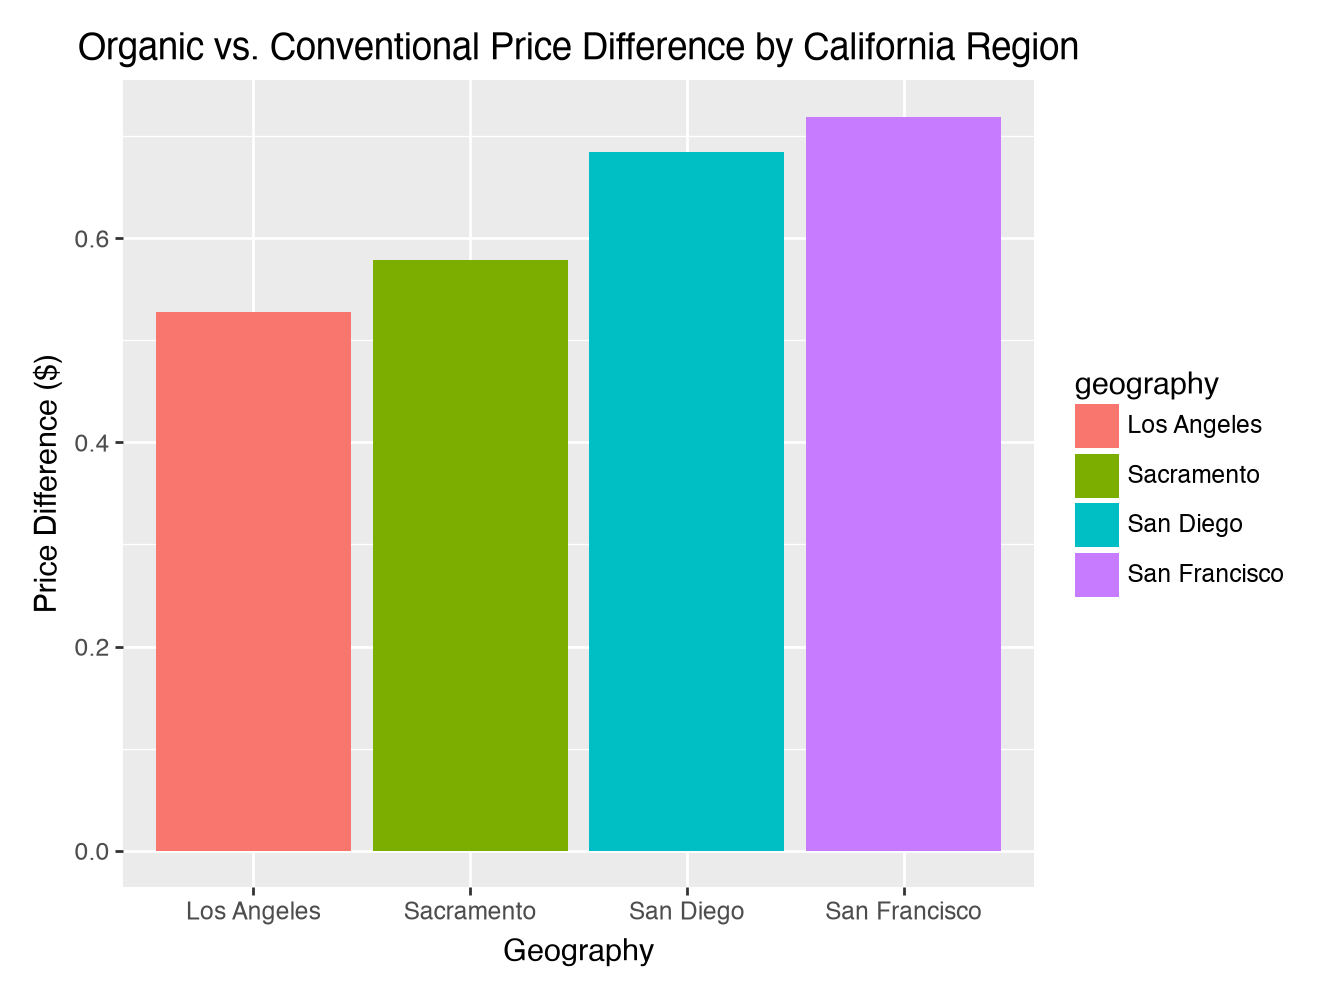

In [45]:
from plotnine import *

(ggplot(avg_price_california, aes(x="geography", y="price_diff", fill="geography"))
 + geom_col()
 + labs(
     title="Organic vs. Conventional Price Difference by California Region",
     x="Geography",
     y="Price Difference ($)"
 )
)

**8. The following plot shows, for all four California regions, the proportion of the average Hass avocado sales that are small, large, or extra large; conventional vs. organic. Recreate the plot; you do not have to replicate the exact finishing touches - e.g., color, theme - but your plot should resemble the content of this plot.**

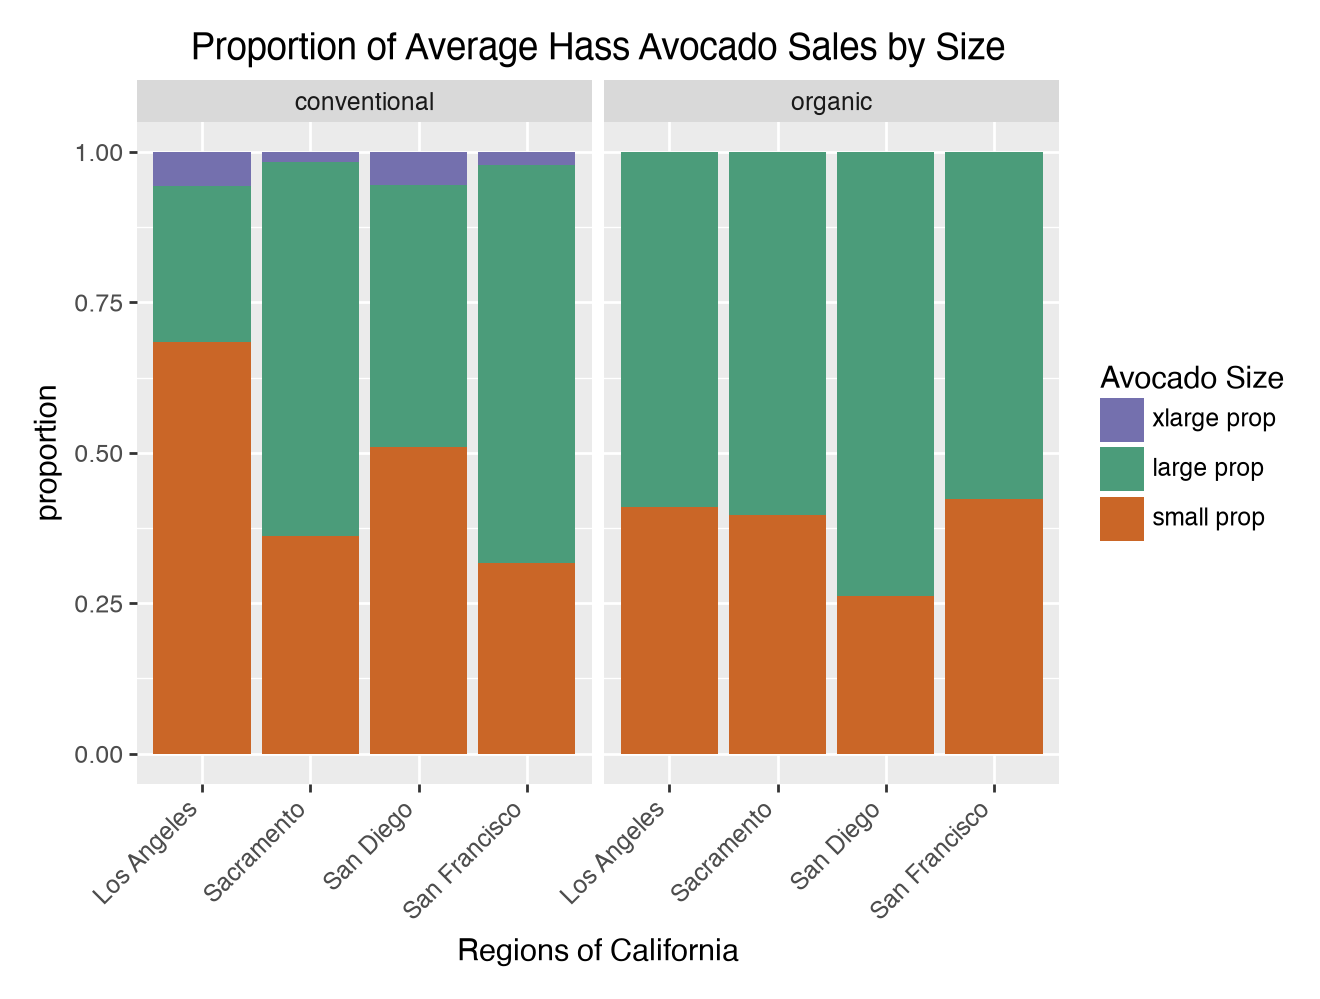

In [58]:
df_proportions = df_california_avocado.groupby(["geography", "type"])[["small volume", "large volume", "xlarge volume"]].sum().reset_index()

df_proportions["total volume"] = df_proportions["small volume"] + df_proportions["large volume"] + df_proportions["xlarge volume"]
df_proportions["small prop"] = df_proportions["small volume"] / df_proportions["total volume"]
df_proportions["large prop"] = df_proportions["large volume"] / df_proportions["total volume"]
df_proportions["xlarge prop"] = df_proportions["xlarge volume"] / df_proportions["total volume"]

df_proportions_melted = df_proportions.melt(id_vars=["geography", "type"], value_vars=["small prop", "large prop", "xlarge prop"],var_name="size category",value_name="proportion")

size_order = ["xlarge prop", "large prop", "small prop"]
df_proportions_melted["size category"] = pd.Categorical(df_proportions_melted["size category"], categories=size_order, ordered=True)

size_colors = {
    "small prop": "#CA6627",
    "large prop": "#4B9C7A",
    "xlarge prop": "#7470AE",
}

(ggplot(df_proportions_melted, aes(x="geography", y="proportion", fill="size category"))
 + geom_col(position="stack") # Create stacked bars
 + facet_grid(". ~ type") # Separate plots for conventional vs. organic
 + labs(
     title="Proportion of Average Hass Avocado Sales by Size",
     x="Regions of California",
     y="proportion",
     fill="Avocado Size",
     
 )
 + scale_fill_manual(values=size_colors)
 + theme(
     axis_text_x=element_text(rotation=45, hjust=1), # Rotate x-axis labels for readability
     legend_position="right"
 )
)

**A joke in the media is that Millennials can’t afford houses, because they spend all their money buying avocado toast. Let’s use this data set to address that claim.

Find or assemble a data set of real data, with house prices for these four California regions. Join this data set with your California avocado data set.

Use your new joined data set to make an argument about the relationship between house prices and avocado prices/sales.

Support your argument with a plot.**

In [59]:
df_housing = pd.read_csv("/Users/melaniehuang/Desktop/Machine Learning/Labs/Lab2/housing.csv")
df_housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [66]:
df_housing["city"] = "not important"
# found the longitude and latitude for the cities were looking at
df_housing.loc[df_housing["latitude"].between(33.7, 34.3) & df_housing["longitude"].between(-118.7, -118.1), "city"] = "Los Angeles"
df_housing.loc[df_housing["latitude"].between(32.5, 33.1) & df_housing["longitude"].between(-117.3, -116.9), "city"] = "San Diego"
df_housing.loc[df_housing["latitude"].between(38.4, 38.7) & df_housing["longitude"].between(-121.6, -121.3), "city"] = "Sacramento"
df_housing.loc[df_housing["latitude"].between(37.6, 37.9) & df_housing["longitude"].between(-122.6, -122.3), "city"] = "San Francisco"
 
df_housing
 
 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,city
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,not important
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,not important
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,not important
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,not important
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,not important
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,not important
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,not important
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,not important
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,not important


In [73]:
# merge by cities to see house value, avocado price, and volume in the areas 
city_housing = (df_housing.groupby("city")["median_house_value"].mean().reset_index().rename(columns={"median_house_value": "avg_house_value"}))
#city_housing
avg_price_california = (avg_price_california.rename(columns={"geography": "city"}))
city_avocado = city_housing.merge(avg_price_california, on="city")

city_avocado["avg_avocado_price"] = city_avocado[["organic", "conventional"]].mean(axis=1)

city_avocado

,city,avg_house_value,conventional,organic,price_diff,avg_avocado_price
0,Los Angeles,246650.139565,1.047124,1.574902,0.527778,1.311013
1,Sacramento,123678.330373,1.295359,1.873856,0.578497,1.584608
2,San Diego,197458.174591,1.113856,1.798366,0.684510,1.456111
3,San Francisco,325710.789474,1.400490,2.119444,0.718954,1.759967


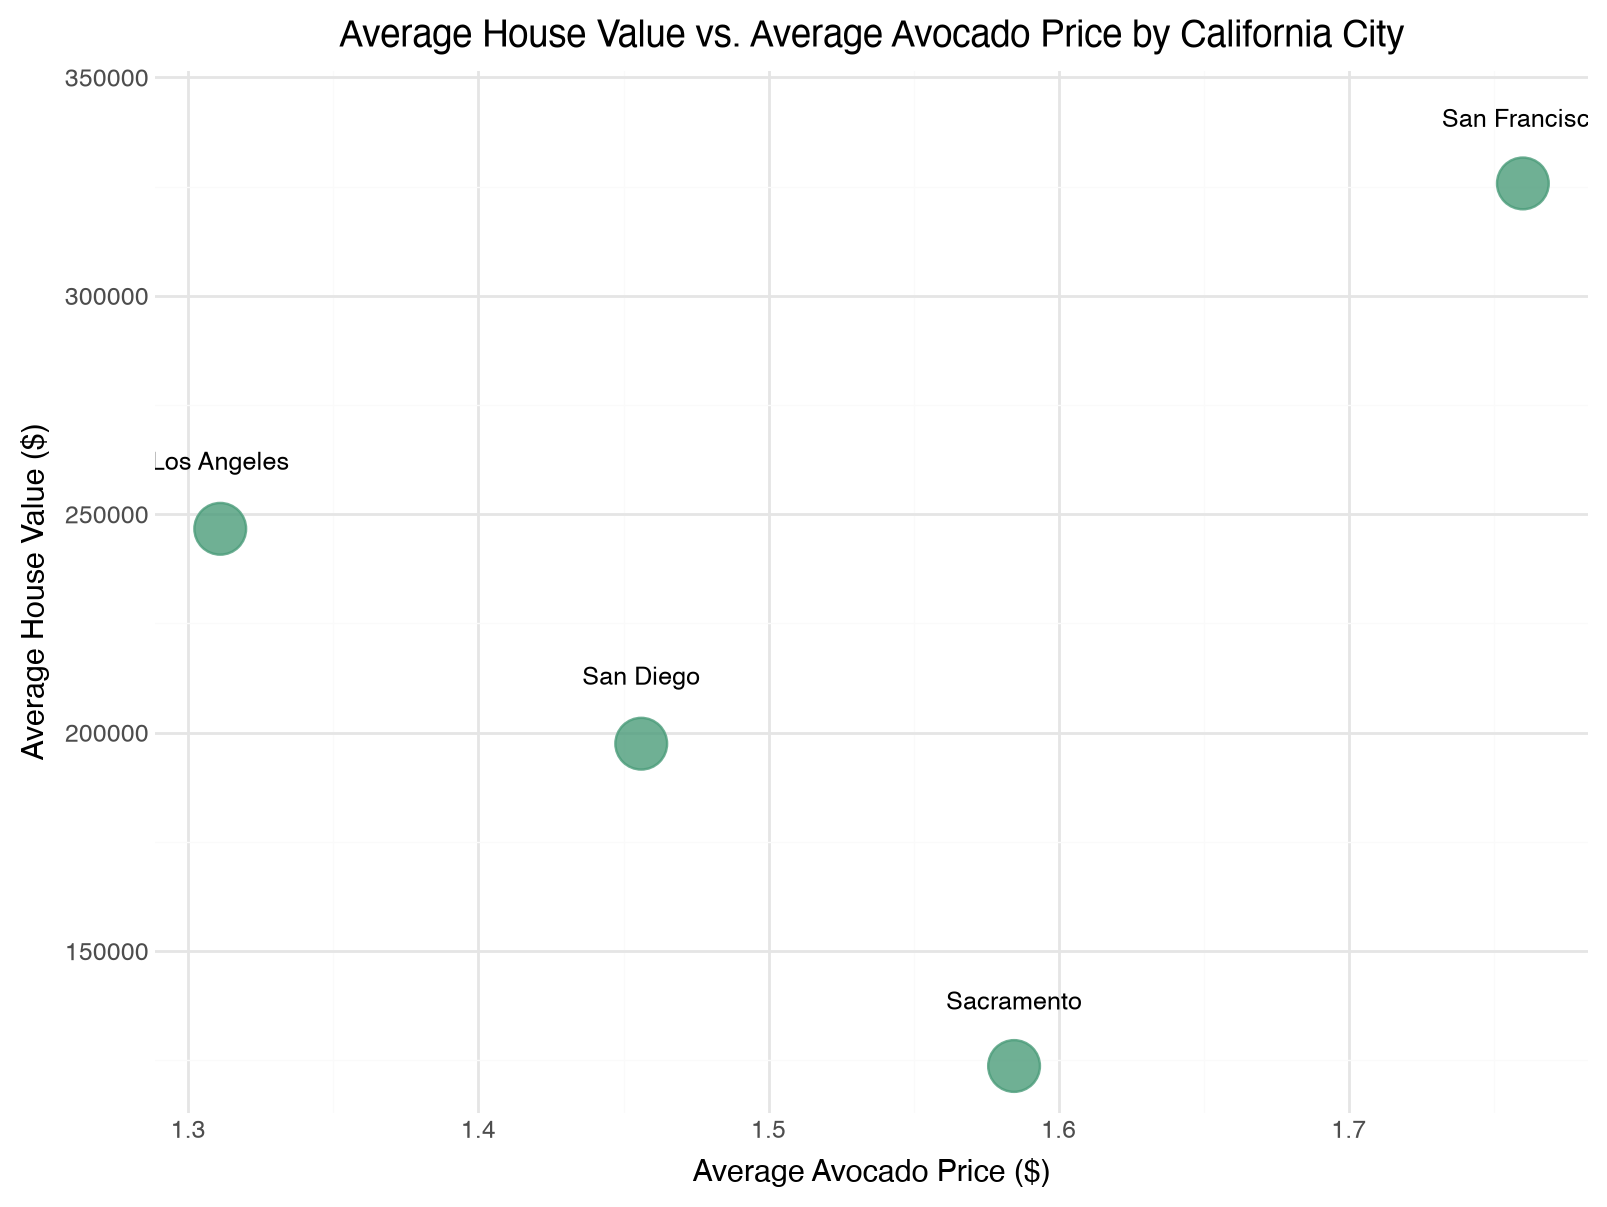

In [78]:
(ggplot(city_avocado, aes(x="avg_avocado_price", y="avg_house_value"))
    + geom_point(color="#4B9C7A", alpha=0.8, size=10)
    + geom_text(aes(label="city"), nudge_y=15000, size=9, show_legend=False)
    + labs(
        title="Average House Value vs. Average Avocado Price by California City",
        x="Average Avocado Price ($)",
        y="Average House Value ($)",
    )
    + theme_minimal()
    + theme(figure_size=(8, 6))
)

**san Francisco has the greatest average avocado price and average housing prices overall.**